In [1]:
!pip install Sastrawi

   ---------------------------------------- 0.0/209.7 kB ? eta -:--:--
   ---------------------------------------- 0.0/209.7 kB ? eta -:--:--
   ---------------------------------------- 0.0/209.7 kB ? eta -:--:--
   ---------------------------------------- 0.0/209.7 kB ? eta -:--:--
   ---------------------------------------- 0.0/209.7 kB ? eta -:--:--
   - -------------------------------------- 10.2/209.7 kB ? eta -:--:--
   - -------------------------------------- 10.2/209.7 kB ? eta -:--:--
   - -------------------------------------- 10.2/209.7 kB ? eta -:--:--
   ----- --------------------------------- 30.7/209.7 kB 187.9 kB/s eta 0:00:01
   ------- ------------------------------- 41.0/209.7 kB 196.9 kB/s eta 0:00:01
   ----------- --------------------------- 61.4/209.7 kB 218.8 kB/s eta 0:00:01
   --------------- ----------------------- 81.9/209.7 kB 270.5 kB/s eta 0:00:01
   ----------------- --------------------- 92.2/209.7 kB 275.8 kB/s eta 0:00:01
   ----------------- --------

In [2]:
import pandas as pd
import numpy as np
import re
import string

# NLP
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

In [5]:
df = pd.read_csv('data_bpjs.csv')
df.head()

,Date,Username,Comment
0,12/1/2025,worksfess,work! sender gak nyaman sama lingkungan kerja ...
1,12/2/2025,mollypinki,@undipmfs2 waktu itu aku case-nya juga sama ka...
2,12/2/2025,grok,@AntonSubagia @Bank_Joee_ @susno2g @Jediimar @...
3,12/3/2025,yourrsse,@BPJSKesehatanRI min kalo mau pindah dari bpjs...
4,12/3/2025,hamiyaaaa,Bpjs pbi akhir bln kemarin serentak pada nonak...


In [6]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)  # hapus link
    text = re.sub(r'@\w+', '', text)     # hapus mention
    text = re.sub(r'#\w+', '', text)     # hapus hashtag
    text = re.sub(r'\d+', '', text)      # hapus angka
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip()
    text = stemmer.stem(text)            # stemming
    return text

df['clean_comment'] = df['Comment'].apply(clean_text)
df[['Comment', 'clean_comment']].head()

,Comment,clean_comment
0,work! sender gak nyaman sama lingkungan kerja ...,work sender gak nyaman sama lingkung kerja yan...
1,@undipmfs2 waktu itu aku case-nya juga sama ka...,waktu itu aku casenya juga sama kayak kamu aku...
2,@AntonSubagia @Bank_Joee_ @susno2g @Jediimar @...,haha poin bagus benar bayi baru lahir harus da...
3,@BPJSKesehatanRI min kalo mau pindah dari bpjs...,min kalo mau pindah dari bpjs serta mandiri ke...
4,Bpjs pbi akhir bln kemarin serentak pada nonak...,bpjs pbi akhir bln kemarin serentak pada nonak...


In [ ]:
def labeling(text):
    if any(word in text for word in ['tidak', 'kenapa', 'bingung', 'nonaktif', 'tunggakan', 'sakit', 'toxic', 'diem', 'diam', 'non', 'henti', 'pusing', 'takut', 'kecewa', 'muak', 'marah', 'emosi', 'ironis', 'mengecewakan', 'dirampas', 'jelek', 'susah', 'sulit', 'pusing', 'cabut', 'miskin', 'lama', 'pindah']):
        return 'negatif'
    elif any(word in text for word in ['bagus', 'mudah', 'terbantu', 'mampu', 'gratis', 'adil']):
        return 'positif'
    else:
        return 'netral'

df['sentiment'] = df['clean_comment'].apply(labeling)
df['sentiment'].value_counts()

sentiment
negatif    307
netral     231
positif     38
Name: count, dtype: int64

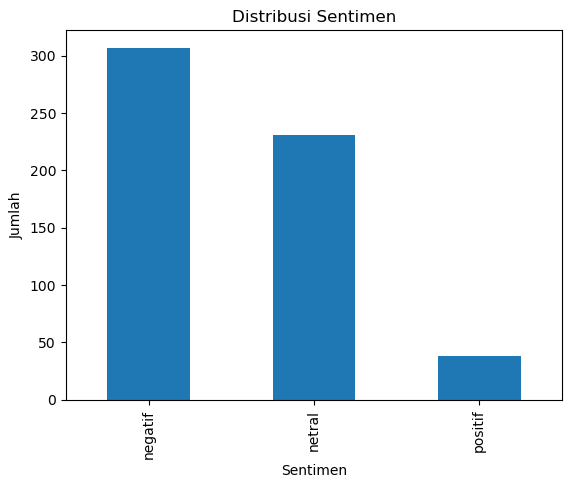

In [67]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar')
plt.title('Distribusi Sentimen')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah')
plt.show()

In [55]:
X = df['clean_comment']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [56]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [57]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [58]:
y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7413793103448276
              precision    recall  f1-score   support

     negatif       0.73      0.88      0.80        58
      netral       0.76      0.74      0.75        47
     positif       0.00      0.00      0.00        11

    accuracy                           0.74       116
   macro avg       0.50      0.54      0.52       116
weighted avg       0.67      0.74      0.70       116



c:\Users\maulida\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\maulida\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\maulida\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [59]:
df['Date'] = pd.to_datetime(df['Date'])
df.groupby(df['Date'].dt.date)['sentiment'].value_counts()

Date        sentiment
2025-12-01  negatif       1
2025-12-02  negatif       1
            netral        1
2025-12-03  netral        2
            negatif       1
                         ..
2026-03-01  negatif       2
2026-03-02  netral       11
            negatif       6
            positif       1
2026-03-03  netral        1
Name: count, Length: 151, dtype: int64

In [60]:
!pip install wordcloud

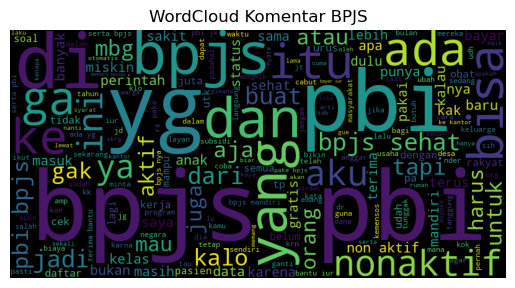

In [61]:
from wordcloud import WordCloud

text = ' '.join(df['clean_comment'])
wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc)
plt.axis('off')
plt.title("WordCloud Komentar BPJS")
plt.show()